# Market_Prediction agent


Fine-tunes **FinBERT** for LOW / MODERATE / HIGH fundamental risk classification.

Uses:
- `data/silver/silver_edgar_*.csv`
- optional project splits: `data/gold/split_train.csv`, `data/gold/split_val.csv`

In [1]:
# Cell 1 — GPU Check

import torch

print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU: ", torch.cuda.get_device_name(0))
    print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

CUDA: False
Device: cpu


In [2]:
!pip install -U transformers datasets accelerate evaluate sentencepiece protobuf scikit-learn pandas numpy matplotlib seaborn torch torchvision torchaudio vaderSentiment

In [3]:
# Cell 2 — Imports

import os, glob, math, random, warnings, json
from pathlib import Path

import numpy as np
import pandas as pd
from datasets import Dataset

import torch

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT.name != "Data298A--Masters-Project" and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

SILVER_DIR = PROJECT_ROOT / "data" / "silver"
GOLD_DIR = PROJECT_ROOT / "data" / "gold"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "fundamental_agent_finbert"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("SILVER_DIR:", SILVER_DIR)
print("GOLD_DIR:", GOLD_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

c:\Users\venkata.ADS-R15-836-07.000\Data298A--Masters-Project\data298a\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PROJECT_ROOT: c:\Users\venkata.ADS-R15-836-07.000\Data298A--Masters-Project
SILVER_DIR: c:\Users\venkata.ADS-R15-836-07.000\Data298A--Masters-Project\data\silver
GOLD_DIR: c:\Users\venkata.ADS-R15-836-07.000\Data298A--Masters-Project\data\gold
OUTPUT_DIR: c:\Users\venkata.ADS-R15-836-07.000\Data298A--Masters-Project\outputs\fundamental_agent_finbert


In [4]:
# Cell 3 — Config

MODEL_NAME = "ProsusAI/finbert"
MAX_LEN = 180
EPOCHS = 4
BATCH_SIZE = 16
LR = 2e-5

LABELS = ["LOW", "MODERATE", "HIGH"]
LABEL2ID = {"LOW": 0, "MODERATE": 1, "HIGH": 2}
ID2LABEL = {0: "LOW", 1: "MODERATE", 2: "HIGH"}

In [5]:
# Cell 4 — Load SEC EDGAR Silver Files

edgar_files = glob.glob(str(SILVER_DIR / "silver_edgar_*.csv"))

if not edgar_files:
    raise FileNotFoundError(f"No silver_edgar_*.csv files found in {SILVER_DIR}")

dfs = []
for file in edgar_files:
    temp = pd.read_csv(file)
    temp = temp.loc[:, ~temp.columns.str.contains("^Unnamed")]
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

print("Loaded EDGAR rows:", df.shape)
display(df.head())
print(df.columns.tolist())

Loaded EDGAR rows: (1664, 17)


,ticker,company,end_date,form,filed,cash_usd_m,long_term_debt,net_income_usd_m,operating_income_usd_m,revenue,revenue_alt,shares_outstanding,stockholders_equity_usd_m,total_assets_usd_m,total_liabilities_usd_m,eps_basic,eps_diluted
0,A,"AGILENT TECHNOLOGIES, INC.",2019-10-31,10-K,2020-12-18,1382.0,NaN,719.0,941.0,NaN,5.163000e+09,309000000.0,4748.0,9452.0,4704.0,NaN,NaN
1,A,"AGILENT TECHNOLOGIES, INC.",2020-10-31,10-K,2022-12-21,1441.0,NaN,719.0,846.0,NaN,5.339000e+09,306000000.0,4873.0,9627.0,4754.0,NaN,NaN
2,A,"AGILENT TECHNOLOGIES, INC.",2021-10-31,10-K,2023-12-20,1484.0,2.729000e+09,1210.0,1347.0,NaN,6.319000e+09,302000000.0,5389.0,10705.0,5316.0,NaN,NaN
3,A,"AGILENT TECHNOLOGIES, INC.",2022-10-31,10-K,2024-12-20,1053.0,2.733000e+09,1254.0,1618.0,NaN,6.848000e+09,295259092.0,5305.0,10532.0,5227.0,NaN,NaN
4,A,"AGILENT TECHNOLOGIES, INC.",2023-10-31,10-K,2025-12-22,1590.0,2.735000e+09,1240.0,1350.0,NaN,6.833000e+09,292123241.0,5845.0,10763.0,4918.0,NaN,NaN


['ticker', 'company', 'end_date', 'form', 'filed', 'cash_usd_m', 'long_term_debt', 'net_income_usd_m', 'operating_income_usd_m', 'revenue', 'revenue_alt', 'shares_outstanding', 'stockholders_equity_usd_m', 'total_assets_usd_m', 'total_liabilities_usd_m', 'eps_basic', 'eps_diluted']


In [6]:
# Cell 5 — Create Fundamental Risk Labels

def safe_float(x, default=0.0):
    try:
        if pd.isna(x):
            return default
        x = float(x)
        if math.isnan(x) or math.isinf(x):
            return default
        return x
    except Exception:
        return default

def make_fundamental_score(row):
    cash = safe_float(row.get("cash_usd_m"), 0)
    debt = safe_float(row.get("long_term_debt"), 0)
    net_income = safe_float(row.get("net_income_usd_m"), 0)
    operating_income = safe_float(row.get("operating_income_usd_m"), 0)
    revenue = safe_float(row.get("revenue"), 0)
    equity = safe_float(row.get("stockholders_equity"), 0)

    debt_to_cash = debt / (cash + 1)
    debt_to_equity = debt / (equity + 1) if equity > 0 else 3
    profit_margin = net_income / (revenue + 1)
    operating_margin = operating_income / (revenue + 1)

    return (
        min(debt_to_cash / 5, 1) * 2.5 +
        min(debt_to_equity / 2, 1) * 2.5 +
        (1 - max(min(profit_margin / 0.20, 1), -1)) * 2.5 +
        (1 - max(min(operating_margin / 0.25, 1), -1)) * 2.5
    )

df["fundamental_risk_score"] = df.apply(make_fundamental_score, axis=1)

low_cut = df["fundamental_risk_score"].quantile(0.33)
high_cut = df["fundamental_risk_score"].quantile(0.66)

def assign_label(score):
    if score <= low_cut:
        return "LOW"
    if score <= high_cut:
        return "MODERATE"
    return "HIGH"

df["risk_label"] = df["fundamental_risk_score"].apply(assign_label)

print(df["risk_label"].value_counts())
print("Low cut:", low_cut)
print("High cut:", high_cut)

risk_label
HIGH        566
LOW         549
MODERATE    549
Name: count, dtype: int64
Low cut: 7.499995165491064
High cut: 9.99999111004699


In [7]:
# Cell 6 — Convert Rows to Text

def get_value(row, candidates, default="unknown"):
    for c in candidates:
        if c in row.index and pd.notna(row[c]):
            return row[c]
    return default

def create_text(row):
    ticker = get_value(row, ["ticker"])
    company = get_value(row, ["company"])
    end_date = get_value(row, ["end_date"])
    form = get_value(row, ["form"])

    cash = get_value(row, ["cash_usd_m"])
    debt = get_value(row, ["long_term_debt"])
    net_income = get_value(row, ["net_income_usd_m"])
    operating_income = get_value(row, ["operating_income_usd_m"])
    revenue = get_value(row, ["revenue"])
    equity = get_value(row, ["stockholders_equity"])

    return (
        f"Company {company} with ticker {ticker} filed {form} for period ending {end_date}. "
        f"Cash is {cash} million USD. Long-term debt is {debt} million USD. "
        f"Net income is {net_income} million USD. Operating income is {operating_income} million USD. "
        f"Revenue is {revenue} million USD. Stockholders equity is {equity} million USD. "
        f"Classify the company's fundamental financial risk as LOW, MODERATE, or HIGH."
    )

df["text"] = df.apply(create_text, axis=1)
df["label"] = df["risk_label"].map(LABEL2ID)
df["ticker_upper"] = df["ticker"].astype(str).str.upper()
df = df.dropna(subset=["text", "label"])
df["label"] = df["label"].astype(int)

display(df[["ticker", "risk_label", "label", "text"]].head())

,ticker,risk_label,label,text
0,A,LOW,0,"Company AGILENT TECHNOLOGIES, INC. with ticker..."
1,A,LOW,0,"Company AGILENT TECHNOLOGIES, INC. with ticker..."
2,A,LOW,0,"Company AGILENT TECHNOLOGIES, INC. with ticker..."
3,A,LOW,0,"Company AGILENT TECHNOLOGIES, INC. with ticker..."
4,A,LOW,0,"Company AGILENT TECHNOLOGIES, INC. with ticker..."


In [8]:
# Cell 7 — Train / Validation Split

train_split_path = GOLD_DIR / "split_train.csv"
val_split_path = GOLD_DIR / "split_val.csv"

if train_split_path.exists() and val_split_path.exists():
    split_train = pd.read_csv(train_split_path)
    split_val = pd.read_csv(val_split_path)

    train_tickers = set(split_train["ticker"].astype(str).str.upper())
    val_tickers = set(split_val["ticker"].astype(str).str.upper())

    train_df = df[df["ticker_upper"].isin(train_tickers)].copy()
    val_df = df[df["ticker_upper"].isin(val_tickers)].copy()
    print("Using ticker-level project split files.")
else:
    df["end_date_parsed"] = pd.to_datetime(df["end_date"], errors="coerce")
    train_df = df[df["end_date_parsed"].dt.year <= 2021].copy()
    val_df = df[df["end_date_parsed"].dt.year > 2021].copy()
    print("Using temporal split fallback.")

if len(train_df) == 0 or len(val_df) == 0:
    raise ValueError("Train or validation dataframe is empty. Check split files and ticker columns.")

print("Train rows:", train_df.shape)
print("Val rows:", val_df.shape)
print("Train labels:")
print(train_df["risk_label"].value_counts())
print("Val labels:")
print(val_df["risk_label"].value_counts())

Using ticker-level project split files.
Train rows: (1179, 22)
Val rows: (244, 22)
Train labels:
risk_label
HIGH        425
MODERATE    411
LOW         343
Name: count, dtype: int64
Val labels:
risk_label
HIGH        98
LOW         80
MODERATE    66
Name: count, dtype: int64


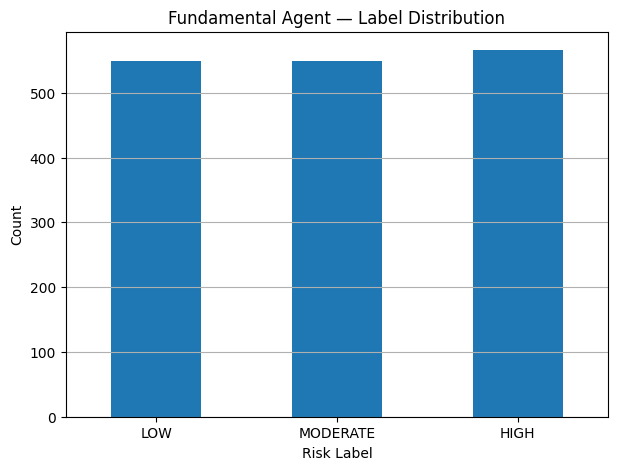

In [17]:
# Label Distribution Plot

label_counts = df["risk_label"].value_counts().reindex(LABELS)

plt.figure(figsize=(7, 5))
label_counts.plot(kind="bar")

plt.xlabel("Risk Label")
plt.ylabel("Count")
plt.title("Fundamental Agent — Label Distribution")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

In [9]:
# Cell 8 — HuggingFace Datasets and Tokenization

train_dataset = Dataset.from_pandas(train_df[["text", "label"]], preserve_index=False)
val_dataset = Dataset.from_pandas(val_df[["text", "label"]], preserve_index=False)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

train_dataset = train_dataset.remove_columns(["text"])
val_dataset = val_dataset.remove_columns(["text"])

train_dataset.set_format("torch")
val_dataset.set_format("torch")

print(train_dataset)
print(val_dataset)

Map: 100%|██████████| 244/244 [00:00<00:00, 15174.00 examples/s]

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 1179
})
Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 244
})


In [10]:
# Cell 9 — Model

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    ignore_mismatched_sizes=True
).to(device)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [11]:
# Cell 10 — Metrics

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro", zero_division=0)
    }

In [12]:
# Cell 11 — Train

training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LR,
    weight_decay=0.01,
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    report_to="none",
    fp16=torch.cuda.is_available()
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer.train()
trainer.save_model(str(OUTPUT_DIR))
tokenizer.save_pretrained(str(OUTPUT_DIR))

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.732500,0.596721,0.758197,0.734001
2,0.389100,0.460380,0.856557,0.843632
3,0.350000,0.384893,0.860656,0.847061
4,0.262700,0.334166,0.872951,0.860137


('c:\\Users\\venkata.ADS-R15-836-07.000\\Data298A--Masters-Project\\outputs\\fundamental_agent_finbert\\tokenizer_config.json',
 'c:\\Users\\venkata.ADS-R15-836-07.000\\Data298A--Masters-Project\\outputs\\fundamental_agent_finbert\\special_tokens_map.json',
 'c:\\Users\\venkata.ADS-R15-836-07.000\\Data298A--Masters-Project\\outputs\\fundamental_agent_finbert\\vocab.txt',
 'c:\\Users\\venkata.ADS-R15-836-07.000\\Data298A--Masters-Project\\outputs\\fundamental_agent_finbert\\added_tokens.json',
 'c:\\Users\\venkata.ADS-R15-836-07.000\\Data298A--Masters-Project\\outputs\\fundamental_agent_finbert\\tokenizer.json')

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_macro_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,1.6889,19.203634,0.000019,0.135135,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0688,15.125418,0.000019,0.270270,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.9106,7.976185,0.000018,0.405405,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.9331,7.476944,0.000017,0.540541,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.7986,7.128868,0.000017,0.675676,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


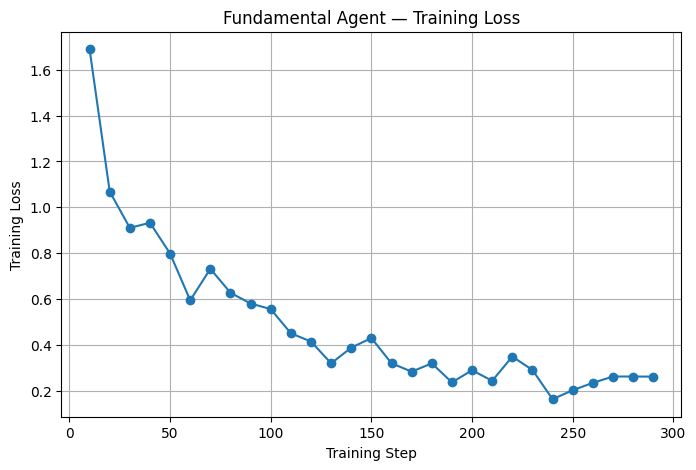

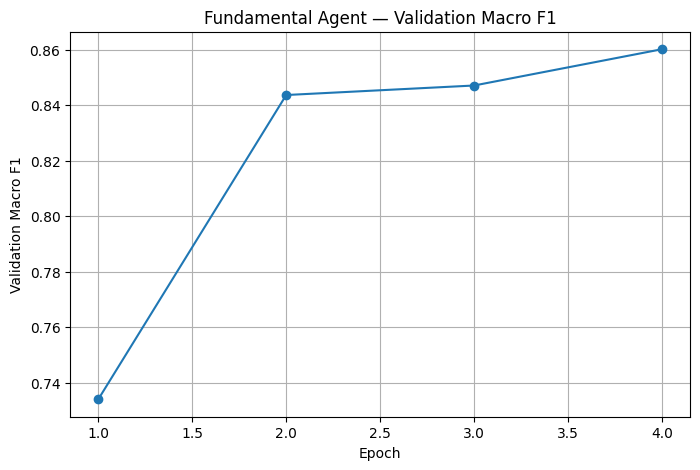

In [15]:
# Plot training history from Trainer logs

import pandas as pd
import matplotlib.pyplot as plt

logs = trainer.state.log_history
history_df = pd.DataFrame(logs)

display(history_df.head())

# Loss plot
loss_df = history_df[history_df["loss"].notna()] if "loss" in history_df.columns else pd.DataFrame()

if not loss_df.empty:
    plt.figure(figsize=(8, 5))
    plt.plot(loss_df["step"], loss_df["loss"], marker="o")
    plt.xlabel("Training Step")
    plt.ylabel("Training Loss")
    plt.title("Fundamental Agent — Training Loss")
    plt.grid(True)
    plt.show()

# Evaluation Macro F1 plot
if "eval_macro_f1" in history_df.columns:
    eval_df = history_df[history_df["eval_macro_f1"].notna()]

    plt.figure(figsize=(8, 5))
    plt.plot(eval_df["epoch"], eval_df["eval_macro_f1"], marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Validation Macro F1")
    plt.title("Fundamental Agent — Validation Macro F1")
    plt.grid(True)
    plt.show()

In [13]:
# Cell 12 — Final Evaluation

pred_output = trainer.predict(val_dataset)
preds = np.argmax(pred_output.predictions, axis=1)
labels = pred_output.label_ids

print(classification_report(labels, preds, target_names=LABELS, digits=4, zero_division=0))
print("Macro F1:", f1_score(labels, preds, average="macro", zero_division=0))
print("Accuracy:", accuracy_score(labels, preds))
print("Confusion matrix:")
print(confusion_matrix(labels, preds))

              precision    recall  f1-score   support

         LOW     0.9275    0.8000    0.8591        80
    MODERATE     0.7536    0.7879    0.7704        66
        HIGH     0.9151    0.9898    0.9510        98

    accuracy                         0.8730       244
   macro avg     0.8654    0.8592    0.8601       244
weighted avg     0.8755    0.8730    0.8720       244

Macro F1: 0.860137055070599
Accuracy: 0.8729508196721312
Confusion matrix:
[[64 16  0]
 [ 5 52  9]
 [ 0  1 97]]


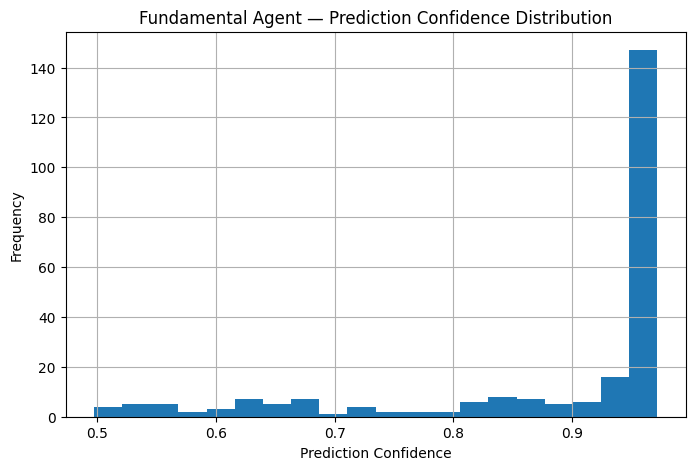

In [18]:
# Prediction Confidence Distribution

probs = torch.softmax(torch.tensor(pred_output.predictions), dim=1).numpy()
confidences = probs.max(axis=1)

plt.figure(figsize=(8, 5))
plt.hist(confidences, bins=20)

plt.xlabel("Prediction Confidence")
plt.ylabel("Frequency")
plt.title("Fundamental Agent — Prediction Confidence Distribution")
plt.grid(True)
plt.show()

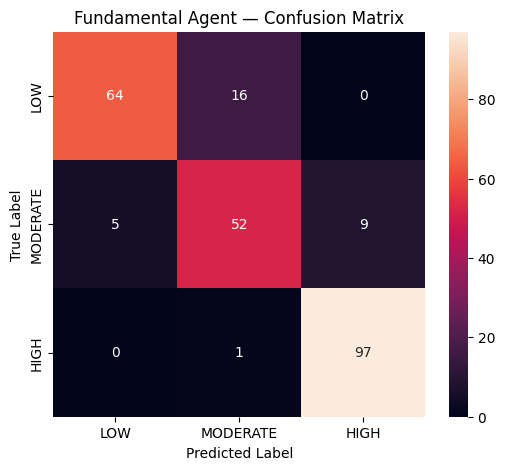

In [16]:
# Confusion Matrix Plot

import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=LABELS,
    yticklabels=LABELS
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Fundamental Agent — Confusion Matrix")
plt.show()

In [14]:
# Cell 13 — Structured Fundamental Agent Output

def calculate_risk_score(label, confidence):
    if label == "LOW":
        return round(max(1.0, 3.5 - confidence * 1.5), 2)
    if label == "MODERATE":
        return round(4.25 + confidence * 1.75, 2)
    return round(min(10.0, 6.25 + confidence * 2.5), 2)

def generate_signals(row):
    positive, negative = [], []

    cash = safe_float(row.get("cash_usd_m"), 0)
    debt = safe_float(row.get("long_term_debt"), 0)
    net_income = safe_float(row.get("net_income_usd_m"), 0)
    operating_income = safe_float(row.get("operating_income_usd_m"), 0)
    revenue = safe_float(row.get("revenue"), 0)
    equity = safe_float(row.get("stockholders_equity"), 0)

    debt_to_cash = debt / (cash + 1)
    debt_to_equity = debt / (equity + 1) if equity > 0 else 999
    profit_margin = net_income / (revenue + 1)
    operating_margin = operating_income / (revenue + 1)

    if debt_to_cash <= 2:
        positive.append("Cash reserves are reasonable relative to long-term debt.")
    else:
        negative.append("Long-term debt is elevated relative to cash reserves.")

    if debt_to_equity <= 1:
        positive.append("Debt-to-equity ratio does not indicate severe leverage pressure.")
    elif debt_to_equity <= 2:
        negative.append("Debt-to-equity ratio indicates moderate leverage exposure.")
    else:
        negative.append("Debt-to-equity ratio indicates high leverage pressure.")

    if profit_margin >= 0.08:
        positive.append("Profit margin indicates positive earnings strength.")
    elif profit_margin >= 0:
        negative.append("Profit margin is low, limiting financial flexibility.")
    else:
        negative.append("Negative profit margin indicates profitability stress.")

    if operating_margin >= 0.10:
        positive.append("Operating margin shows stable core business performance.")
    elif operating_margin >= 0:
        negative.append("Operating margin is thin, suggesting limited operational cushion.")
    else:
        negative.append("Negative operating margin indicates weak core operations.")

    return positive, negative

def fundamental_agent_predict(row):
    text = create_text(row)
    encoded = tokenizer(text, truncation=True, max_length=MAX_LEN, return_tensors="pt").to(device)

    model.eval()
    with torch.no_grad():
        output = model(**encoded)
        probs = torch.softmax(output.logits, dim=1).cpu().numpy()[0]

    pred_id = int(np.argmax(probs))
    risk_label = ID2LABEL[pred_id]
    confidence = round(float(probs[pred_id]), 4)
    risk_score = calculate_risk_score(risk_label, confidence)

    positive, negative = generate_signals(row)

    ticker = str(row.get("ticker", "UNKNOWN")).upper()
    company = str(row.get("company", "UNKNOWN")).replace("\xa0", " ").strip()

    return {
        "agent_name": "fundamental_analysis_agent",
        "ticker": ticker,
        "company": company,
        "risk_score": risk_score,
        "risk_label": risk_label,
        "confidence": confidence,
        "positive_signals": positive,
        "negative_signals": negative,
        "overall_assessment": (
            f"{company} ({ticker}) is classified as {risk_label} fundamental risk. "
            f"The assessment balances profitability, leverage, liquidity, and operating performance."
        ),
        "justification": "The result is generated from SEC EDGAR financial statement indicators."
    }

sample_output = fundamental_agent_predict(df.iloc[0])
print(json.dumps(sample_output, indent=2))

{
  "agent_name": "fundamental_analysis_agent",
  "ticker": "A",
  "company": "AGILENT TECHNOLOGIES, INC.",
  "risk_score": 2.05,
  "risk_label": "LOW",
  "confidence": 0.9697,
  "positive_signals": [
    "Cash reserves are reasonable relative to long-term debt.",
    "Profit margin indicates positive earnings strength.",
    "Operating margin shows stable core business performance."
  ],
  "negative_signals": [
    "Debt-to-equity ratio indicates high leverage pressure."
  ],
  "overall_assessment": "AGILENT TECHNOLOGIES, INC. (A) is classified as LOW fundamental risk. The assessment balances profitability, leverage, liquidity, and operating performance.",
  "justification": "The result is generated from SEC EDGAR financial statement indicators."
}
